In [1]:
import pandas as pd
from results import combine_results, process_results, confusion_matrix, data_process, process_as_binary, score_results, score_results_RMSE, score_results_MAE, score_results_spearman
import json 
import re

train_data = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/VectorDB/train.pkl')


In [2]:
iter_filepath = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/Results/BASELINES_NEW/iterative/prediction_iterative_True_1_14_random_state_42.jsonl'
zs_filepath = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/Results/BASELINES_NEW/train/train_baseline_zero_True_1_13_random_state_42.jsonl'

In [3]:
filepath = iter_filepath

In [4]:
results = {}


individual_result = {}

def extract_json_parts(text):
    # Regex pattern to match JSON content within ```json``` markers
    pattern = r'```json\n({[\s\S]*?})\n```'
    
    # Find all matches
    matches = re.findall(pattern, text)
    
    # Join the matches to form the cleaned text
    cleaned_text = '\n'.join(matches)
    
    return cleaned_text

with open(filepath, 'r') as infile:
    
    data = pd.read_json(infile,lines=True)
    data = data[['custom_id','response']]

for i in range(len(data)):
        
    result = data['response'][i]['body']['choices'][0]['message']['content']
    
    #print(i, result)    
    result = extract_json_parts(result)
    #print(result)
    json_objects = result.replace('{','\n{').split('\n\n')
    
    
    list_reasons = []
    list_json = []
    for obj in json_objects:
        obj = obj.split('{')
        #print(obj)
        obj = obj[1].split('}')
        obj = obj[0]
        obj = '{' + obj + '}'
        print(obj)
        try:
            parsed_obj = json.loads(obj)
        except:
            pass
        list_json.append(parsed_obj['Confidence in Importance Ascription'])
        list_reasons.append(parsed_obj['Reasoning'])

    #print(data["custom_id"][i])
    individual_result[f'{data["custom_id"][i]}'] = [list_reasons,list_json]
    
print(individual_result)

{
    "Case Importance Under Consideration": "3",
    "Confidence in Importance Ascription": 70,
    "Reasoning": "The case involves multiple instances of domestic violence and the failure of the Russian legal system to adequately protect the victims. However, it primarily applies existing case law regarding the state's obligation to protect individuals from torture and inhuman treatment under Article 3. The case highlights systemic issues but does not introduce new legal principles or significantly modify existing case law."
}
{
    "Case Importance Under Consideration": "2",
    "Confidence in Importance Ascription": 80,
    "Reasoning": "The case goes beyond merely applying existing case law by highlighting systemic failures in the Russian legal framework to address domestic violence effectively. It underscores the lack of legal provisions such as restraining orders and the inadequacy of the current legal framework in protecting victims of domestic violence, which could influence fu

In [5]:
individual_results = {}
for k, v in individual_result.items():
    
    #print(v[1])
    max_index = v[1].index(max(v[1]))
    score = {3:1, 2:2, 1:3, 0:4}[max_index]
    individual_results[k] = [score, v[0][max_index]]
    



In [6]:
df = pd.DataFrame(individual_results.items(), columns=['Filename', 'Pred_Importance_iter'])

#df = pd.merge(train_data,df,on='Filename')


In [7]:
df[['Score_iter', 'Reasoning_iter']] = pd.DataFrame(df['Pred_Importance_iter'].tolist(), index=df.index)

In [8]:
df.drop(columns=['Pred_Importance_iter'],inplace=True)


In [9]:
file = zs_filepath

In [10]:
results = {}

individual_result = {}
data = pd.read_json(f'{file}',lines=True)
data = data[['custom_id','response']]

for i in range(len(data)):
    result = data['response'][i]['body']['choices'][0]['message']['content']
    #print(result)
    result = json.loads(result)
    #print(data["custom_id"][i])
    individual_result[f'{data["custom_id"][i]}'] = [result['Case Importance'],result['Reasoning']]
    #print(individual_result)

results[file] = individual_result


In [11]:
normal_results = results[file]

In [12]:
df2 = pd.DataFrame(normal_results.items(), columns=['Filename', 'Pred_Importance'])

In [13]:
df2[['Score_norm', 'Reasoning_norm']] = pd.DataFrame(df2['Pred_Importance'].tolist(), index=df2.index)

In [14]:
df2.drop(columns=['Pred_Importance'],inplace=True)

In [15]:
new_df = pd.merge(df,df2,on='Filename')

In [16]:
train_data['importance']

889    3
928    3
729    3
499    3
801    2
      ..
303    4
389    4
95     4
417    1
762    4
Name: importance, Length: 206, dtype: int64

In [17]:
new_df['Score_norm'] = new_df['Score_norm'].map({'key_case': 1, '1': 2, '2': 3, '3': 4})

In [18]:
final_df = pd.merge(train_data,new_df,on='Filename')

In [19]:
final_df.columns

Index(['Filename', 'Questions', 'Subject Matter', 'appno', 'source_file',
       'doc_date', 'importance', 'keywords_art_3', 'keywords_art_3_text',
       'Subj_Count', 'extracted_apps', 'new_list_length', 'new_list_length_2',
       'Score_iter', 'Reasoning_iter', 'Score_norm', 'Reasoning_norm'],
      dtype='object')

In [20]:
final_df.drop(columns=['Questions','appno','source_file','doc_date','keywords_art_3_text','Subj_Count','extracted_apps','new_list_length','new_list_length_2'],inplace=True)

In [21]:
mismatched_cases = final_df[(final_df['importance'] != final_df['Score_iter']) & (final_df['importance'] != final_df['Score_norm'])]

In [22]:
#want to fix the data for the mismatched cases

#retrieve zero-shot prompts
prompt_path = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/BASELINES_NEW/train_baseline/train_baseline_zero_True_1_13_random_state_42.jsonl'

In [23]:
data = []
with open(prompt_path, 'r') as file:
    for line in file:
        data.append(json.loads(line))

df = pd.DataFrame(data)

In [24]:
MAX_TOKENS = 1000
TEMPERATURE = 0
TOP_P = 1.0
SEED = 42

In [25]:
output = []

for index, row in mismatched_cases.iterrows():
    filename = row['Filename']
    df_row = df[df['custom_id'] == filename]
    if not df_row.empty:
        prompt = df_row.iloc[0]['body']['messages'][0]['content']
    else:
        print(f"No data found for filename: {filename}")
        
    importance = row['importance']
    
    importance = {1: 'key_case', 2: '1', 3: '2', 4: '3'}[importance]
    
    prompt += f'\n The importance level of this case is: {importance}. Please only predict this importance level and provide reasons why the case is importance level {importance}.'
    
    template = {"custom_id": f'{filename}', "method": "POST", "url": "/v1/chat/completions", "body": {"model": "gpt-4o", "messages": [{"role": "user", "content": prompt}],'response_format':{'type': 'json_object'},'max_tokens':MAX_TOKENS,'temperature':TEMPERATURE,'top_p':TOP_P, 'seed':SEED}}

    output.append(template)  

In [26]:
from GPT_Experiments import save_file
output_filepath = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/FINE-TUNE'

save_file(output,filepath=output_filepath,batch_name=f'retrieve_correct_data',experiment = 'finetune')


In [27]:
#LOAD IN MISMATCH CASES

mismatch_filepath = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/Results/FINE-TUNE/retrieve_correct_data.jsonl'

In [28]:
results_mismatch = {}

individual_result = {}
data = pd.read_json(f'{mismatch_filepath}',lines=True)
data = data[['custom_id','response']]

for i in range(len(data)):
    result = data['response'][i]['body']['choices'][0]['message']['content']
    #print(result)
    result = json.loads(result)
    #print(data["custom_id"][i])
    individual_result[f'{data["custom_id"][i]}'] = [result['Case Importance'],result['Reasoning']]
    #print(individual_result)

results_mismatch[file] = individual_result


In [29]:
results_mismatch = results_mismatch[file]

In [30]:
df3 = pd.DataFrame(results_mismatch.items(), columns=['Filename', 'Pred_Importance'])

In [31]:
df3[['Score_norm', 'Reasoning_norm']] = pd.DataFrame(df3['Pred_Importance'].tolist(), index=df3.index)

In [32]:
df3.drop(columns=['Pred_Importance'],inplace=True)

In [33]:
df3.rename(columns={'Score_norm':'Score_mismatch','Reasoning_norm':'Reasoning_mismatch'},inplace=True)

In [34]:
df3

,Filename,Score_mismatch,Reasoning_mismatch
0,001-194607,2,The case is of medium importance because it hi...
1,001-202564,2,The case is of medium importance because it in...
2,001-172622,2,The case is of medium importance because it in...
3,001-149050,2,The case is of medium importance because it go...
4,001-140681,3,The case is classified as importance level 3 b...
5,001-147568,3,The case is classified as importance level 3 b...
6,001-162157,2,The case is of medium importance because it in...
7,001-156202,key_case,This case is of key importance because it addr...
8,001-114695,2,The case is of medium importance because it in...
9,001-200953,3,The case is of low importance because it prima...


In [35]:
final_df = pd.merge(df3,final_df,on='Filename',how='right')

In [36]:
final_df

,Filename,Score_mismatch,Reasoning_mismatch,Subject Matter,importance,keywords_art_3,Score_iter,Reasoning_iter,Score_norm,Reasoning_norm
0,001-194607,2,The case is of medium importance because it hi...,"1. The facts of the cases, as submitted by the...",3,"[350, 90, 596, 193, 633]",1,The case is of key importance as it addresses ...,2,The cases presented involve significant issues...
1,001-202564,2,The case is of medium importance because it in...,A list of the applicants is set out in the app...,3,"[350, 90, 193]",4,The case involves the application of existing ...,2,The case involves significant allegations of v...
2,001-172622,2,The case is of medium importance because it in...,"The applicant, Mr Artush Petrosyan, is an Arme...",3,"[350, 90, 193]",2,The case is of high importance due to its pote...,2,The case involves serious allegations of tortu...
3,001-149050,2,The case is of medium importance because it go...,1. Application no. 32631/09 was lodged on 11 J...,3,"[350, 90, 596, 193]",1,The case is of paramount importance due to its...,1,The case of Sergey Magnitskiy is of paramount ...
4,001-180529,NaN,NaN,"The applicant, Mr Viktor Valeryevich Sukachov,...",2,"[350, 90]",3,The case goes beyond merely applying existing ...,2,The case involves significant allegations of i...
...,...,...,...,...,...,...,...,...,...,...
201,001-126514,NaN,NaN,"The applicant, Mr Mehmet Nuri Tanış, is a Turk...",4,[350],4,The case appears to apply existing case law re...,2,The case involves serious allegations of ill-t...
202,001-142203,NaN,NaN,"1. The applicant, Mr Adrian Drăgan, is a state...",4,"[350, 90, 193]",4,The case involves allegations of poor detentio...,2,The case involves multiple serious allegations...
203,001-112186,NaN,NaN,"The applicant, Mr Stanislav Bogdanovici, is a ...",4,[350],4,The case involves allegations of ill-treatment...,3,The case involves allegations of ill-treatment...
204,001-145069,key_case,This case is of key importance due to several ...,"The applicant, Mr Boris Mozer, is a Moldovan n...",1,"[350, 90, 193]",2,The case is of high importance due to its pote...,2,The case involves serious allegations of viola...


In [37]:
final_df['Score_mismatch'] = final_df['Score_mismatch'].map({'key_case': 1, '1': 2, '2': 3, '3': 4})

In [38]:
new_mismatched_cases = final_df[(final_df['importance'] != final_df['Score_iter']) & (final_df['importance'] != final_df['Score_norm']) & (final_df['importance'] != final_df['Score_mismatch'])]

In [39]:
new_mismatched_cases

,Filename,Score_mismatch,Reasoning_mismatch,Subject Matter,importance,keywords_art_3,Score_iter,Reasoning_iter,Score_norm,Reasoning_norm


In [40]:
def get_final_reasoning(row):
    if row['importance'] == row['Score_iter']:
        return row['Reasoning_iter']
    elif row['importance'] == row['Score_norm']:
        return row['Reasoning_norm']
    elif row['importance'] == row['Score_mismatch']:
        return row['Reasoning_mismatch']
    else:
        return None

final_df['FINAL_REASONING'] = final_df.apply(get_final_reasoning, axis=1)

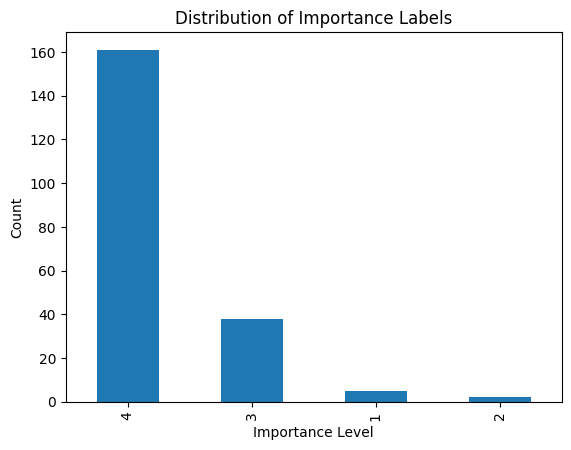

In [41]:
import matplotlib.pyplot as plt

# Show distribution of importance labels
importance_counts = final_df['importance'].value_counts()
importance_counts.plot(kind='bar')
plt.xlabel('Importance Level')
plt.ylabel('Count')
plt.title('Distribution of Importance Labels')
plt.show()

In [42]:
### use data to create finetuning .jsonl 
### create 2 files one with retrieval and one without retrieval
### evaluate the difference on the validation set

#take in batch file 1. Zero-Shot Baseline
zs_batch_filepath = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/BASELINES_NEW/train_baseline/train_baseline_zero_True_1_13_random_state_42.jsonl'

data = []
with open(zs_batch_filepath, 'r') as file:
    for line in file:
        data.append(json.loads(line))

In [43]:
df = pd.DataFrame(data)

In [44]:
final_df

,Filename,Score_mismatch,Reasoning_mismatch,Subject Matter,importance,keywords_art_3,Score_iter,Reasoning_iter,Score_norm,Reasoning_norm,FINAL_REASONING
0,001-194607,3.0,The case is of medium importance because it hi...,"1. The facts of the cases, as submitted by the...",3,"[350, 90, 596, 193, 633]",1,The case is of key importance as it addresses ...,2,The cases presented involve significant issues...,The case is of medium importance because it hi...
1,001-202564,3.0,The case is of medium importance because it in...,A list of the applicants is set out in the app...,3,"[350, 90, 193]",4,The case involves the application of existing ...,2,The case involves significant allegations of v...,The case is of medium importance because it in...
2,001-172622,3.0,The case is of medium importance because it in...,"The applicant, Mr Artush Petrosyan, is an Arme...",3,"[350, 90, 193]",2,The case is of high importance due to its pote...,2,The case involves serious allegations of tortu...,The case is of medium importance because it in...
3,001-149050,3.0,The case is of medium importance because it go...,1. Application no. 32631/09 was lodged on 11 J...,3,"[350, 90, 596, 193]",1,The case is of paramount importance due to its...,1,The case of Sergey Magnitskiy is of paramount ...,The case is of medium importance because it go...
4,001-180529,NaN,NaN,"The applicant, Mr Viktor Valeryevich Sukachov,...",2,"[350, 90]",3,The case goes beyond merely applying existing ...,2,The case involves significant allegations of i...,The case involves significant allegations of i...
...,...,...,...,...,...,...,...,...,...,...,...
201,001-126514,NaN,NaN,"The applicant, Mr Mehmet Nuri Tanış, is a Turk...",4,[350],4,The case appears to apply existing case law re...,2,The case involves serious allegations of ill-t...,The case appears to apply existing case law re...
202,001-142203,NaN,NaN,"1. The applicant, Mr Adrian Drăgan, is a state...",4,"[350, 90, 193]",4,The case involves allegations of poor detentio...,2,The case involves multiple serious allegations...,The case involves allegations of poor detentio...
203,001-112186,NaN,NaN,"The applicant, Mr Stanislav Bogdanovici, is a ...",4,[350],4,The case involves allegations of ill-treatment...,3,The case involves allegations of ill-treatment...,The case involves allegations of ill-treatment...
204,001-145069,1.0,This case is of key importance due to several ...,"The applicant, Mr Boris Mozer, is a Moldovan n...",1,"[350, 90, 193]",2,The case is of high importance due to its pote...,2,The case involves serious allegations of viola...,This case is of key importance due to several ...


In [45]:
len(data)

206

In [46]:
final_df[final_df['Filename'] == '001-146906']

,Filename,Score_mismatch,Reasoning_mismatch,Subject Matter,importance,keywords_art_3,Score_iter,Reasoning_iter,Score_norm,Reasoning_norm,FINAL_REASONING
52,001-146906,NaN,NaN,"The applicant, Ms R.B., is a Hungarian nationa...",2,"[350, 90, 596, 633]",4,The case involves the application of existing ...,2,The case involves significant issues related t...,The case involves significant issues related t...


In [56]:
output_finetune = []
for index, row in df.iterrows():
    filename = row['custom_id']
    
    importance = final_df[final_df['Filename'] == filename]['importance'][index]
    importance = {1: 'key_case', 2: '1', 3: '2', 4: '3'}[importance]
    
    reasoning = final_df[final_df['Filename'] == filename]['FINAL_REASONING'][index]
    user_content = row['body']['messages'][0]
    JSON = {"Case Importance":importance,"Reasoning":reasoning},
    row['body']['messages'].append({'role': 'assistant', 'content': f"{JSON[0]}"})
    
    message = {"messages":[user_content,{'role': 'assistant', 'content': f"{JSON[0]}"}]}
    output_finetune.append(message)


In [57]:
output_filepath = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/FINE-TUNE/finetune_zero_shot_batch_2.jsonl'

with open(output_filepath, 'w') as file:
    for record in output_finetune:
        file.write(json.dumps(record) + '\n')

In [58]:
with open(output_filepath, 'r') as file:
    output_data = [json.loads(line) for line in file]


[{'messages': [{'role': 'user', 'content': " \n        You are a lawyer in the European Court of Human Rights, and your goal is to predict the importance of a case, based on information provided from a communicated case. Importance in a legal setting refers to the significance of a case in terms of its impact on the development of case law.\n        All the cases concern Article 3 of the European Convention of Human Rights, about the prohibition of torture.\n        The following information is provided to you:\n        You will be given a communicated case, including the subject matter of the case.\n        You are given a description of the different levels of importance: key_case: These are the most important and have been selected as key cases and have been selected for publication in the Court's official reports; \n                               1: The case is of high importance. The case makes a significant contribution to the development, clarification or modification of its cas

In [60]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(output_data, test_size=0.2, random_state=42, shuffle=True)

In [61]:
len(train_data), len(test_data)

(164, 42)

In [62]:
train_output_filepath = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/FINE-TUNE/train_data.jsonl'
test_output_filepath = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/FINE-TUNE/test_data.jsonl'

# Write train_data to a .jsonl file
with open(train_output_filepath, 'w') as file:
    for record in train_data:
        file.write(json.dumps(record) + '\n')

# Write test_data to a .jsonl file
with open(test_output_filepath, 'w') as file:
    for record in test_data:
        file.write(json.dumps(record) + '\n')

In [2]:
### open previous batch and use finetuned model
filepath = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/BASELINES_NEW/prediction_baselines_2_True_1_13_random_state_42.jsonl'

data = []
with open(filepath, 'r') as file:
    for line in file:
        data.append(json.loads(line))

df = pd.DataFrame(data)

In [3]:
for index, row in df.iterrows():
    
    row['body']['model'] = 'ft:gpt-4o-2024-08-06:university-of-liverpool:finetune-zero-shot:AqgSEj59'
    

In [5]:
output_filepath = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/BASELINES_NEW/zero_shot_finetune.jsonl'

with open(output_filepath, 'w') as file:
    counter = 0
    for record in df.to_dict(orient='records'):
        file.write(json.dumps(record) + '\n')